# 03 — Работа с вероятностями и калибровка

Ядро проекта. Модель должна выдавать **честную вероятность**, а не ранжирующий скор: решение о ставке строится на EV = p·коэффициент − 1, а размер по Kelly требует истинной p. Мискалибровка → неверный сайзинг → путь к разорению.

**Главная находка (спойлер):** сырые вероятности ансамбля уже хорошо калиброваны (ECE ~0.01) — потому что XGBoost оптимизирует log-loss, proper scoring rule. Калибровку здесь надо **проверять, а не предполагать**. Ниже показываю это на данных: где isotonic помогает, где нет, и почему он всё равно лучше Platt.

Данные: `calibration_probs.parquet` — сырые (`raw_*`) и калиброванные (`cal_*`) вероятности на holdout 2019+ (~27k матчей), генерируются `scripts/calibration_study.py`.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
plt.rcParams['figure.dpi'] = 110

path = Path('../data/results/calibration_probs.parquet')
assert path.exists(), (
    'Нет calibration_probs.parquet. Сгенерируй на сервере:\n'
    '  python scripts/calibration_study.py')
cal = pd.read_parquet(path)
OUTCOMES = ['home', 'draw', 'away']
LABEL = {'home': 'H', 'draw': 'D', 'away': 'A'}
print(f'{len(cal):,} holdout-матчей, сезоны {cal.Season.min()}..{cal.Season.max()}')

27,457 holdout-матчей, сезоны 2019/2020..2025/2026


## 1. Reliability diagrams — до и после калибровки

Идеально калиброванная модель лежит на диагонали: когда говорит 70%, событие случается в ~70%. Строю по каждому исходу отдельно (multiclass = 3 one-vs-rest).

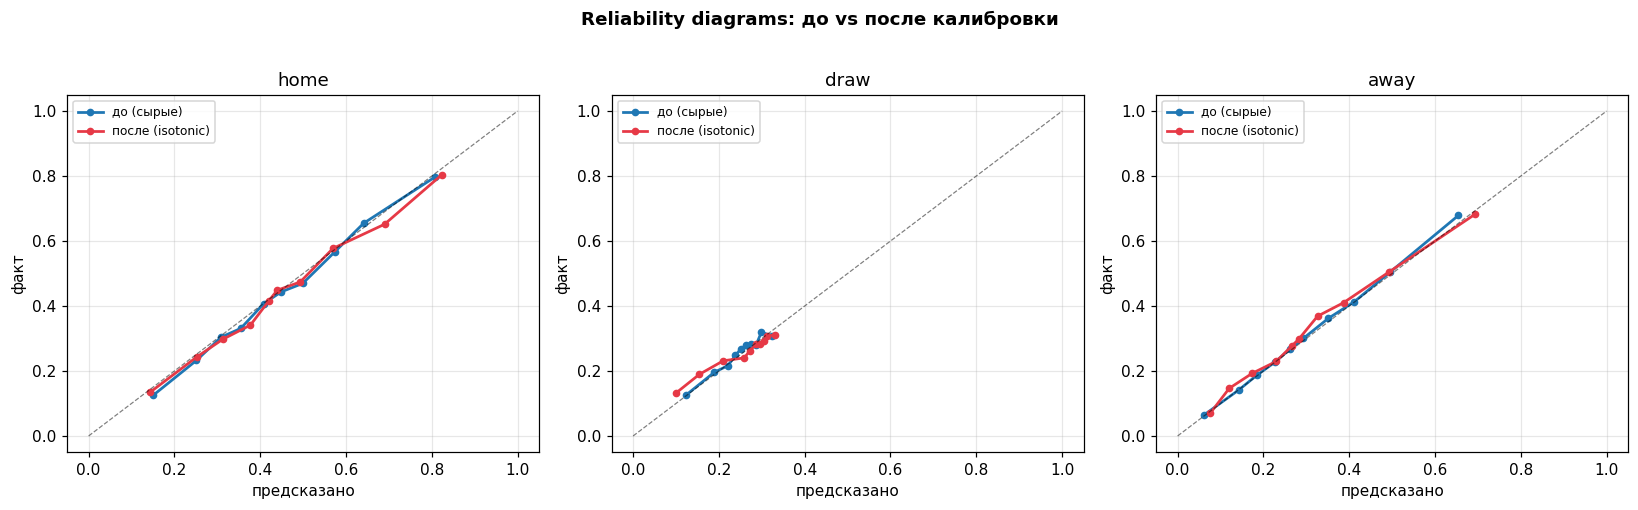

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, out in zip(axes, OUTCOMES):
    y = (cal['target'] == LABEL[out]).astype(int)
    for prefix, name, color in [('raw', 'до (сырые)', '#1f77b4'), ('cal', 'после (isotonic)', '#E63946')]:
        frac, mean_pred = calibration_curve(y, cal[f'{prefix}_{out}'], n_bins=10, strategy='quantile')
        ax.plot(mean_pred, frac, 'o-', color=color, label=name, lw=1.8, ms=4)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f'{out}'); ax.set_xlabel('предсказано'); ax.set_ylabel('факт')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('Reliability diagrams: до vs после калибровки', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. ECE — Expected Calibration Error

Сводит калиброванность в одно число: средневзвешенный по бинам зазор |точность − уверенность|. Меньше = лучше.

Ожидаемо было бы «cal < raw». Но результат ниже честнее и интереснее: raw уже близок к идеалу, а isotonic-шаг модели (обученный на одном val-сезоне + ренормировка трёх независимых калибраторов) местами даже **слегка ухудшает**. Это реальная особенность пайплайна, которую видно только измерив.

In [3]:
def ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    total = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        conf = y_prob[m].mean()
        acc = y_true[m].mean()
        total += (m.sum() / len(y_prob)) * abs(acc - conf)
    return total

rows = []
for out in OUTCOMES:
    y = (cal['target'] == LABEL[out]).astype(int).values
    rows.append({'исход': out,
                 'ECE до': ece(y, cal[f'raw_{out}'].values),
                 'ECE после': ece(y, cal[f'cal_{out}'].values)})
ece_df = pd.DataFrame(rows)
ece_df['улучшение'] = ece_df['ECE до'] - ece_df['ECE после']
print(ece_df.round(4).to_string(index=False))

исход  ECE до  ECE после  улучшение
 home  0.0141     0.0145    -0.0004
 draw  0.0080     0.0163    -0.0083
 away  0.0077     0.0159    -0.0082


## 3. Разложение Брайера (Murphy)

Brier = reliability − resolution + uncertainty. **reliability** (меньше=лучше) — это калиброванность; **resolution** (больше=лучше) — способность различать исходы. Калибровка должна улучшать reliability, не убивая resolution.

In [4]:
def brier_decomp(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    base = y_true.mean()
    rel = res = 0.0
    N = len(y_true)
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        nk = m.sum(); conf = y_prob[m].mean(); acc = y_true[m].mean()
        rel += nk * (conf - acc) ** 2
        res += nk * (acc - base) ** 2
    return rel / N, res / N, base * (1 - base)

for out in OUTCOMES:
    y = (cal['target'] == LABEL[out]).astype(int).values
    r0, s0, u = brier_decomp(y, cal[f'raw_{out}'].values)
    r1, s1, _ = brier_decomp(y, cal[f'cal_{out}'].values)
    print(f'{out:5s}  reliability {r0:.4f}->{r1:.4f}   resolution {s0:.4f}->{s1:.4f}   uncertainty {u:.4f}')

home   reliability 0.0002->0.0004   resolution 0.0361->0.0363   uncertainty 0.2455
draw   reliability 0.0001->0.0006   resolution 0.0025->0.0028   uncertainty 0.1886
away   reliability 0.0001->0.0004   resolution 0.0301->0.0301   uncertainty 0.2156


## 4. Обоснование выбора метода: Isotonic vs Platt

Использую **Isotonic Regression**. Проверю против **Platt (sigmoid)** честно: делю holdout пополам, обучаю калибратор на одной половине, меряю ECE/Brier на другой. Isotonic непараметричен (гибкий, нужны данные), Platt параметричен (устойчив на малой выборке).

In [5]:
rng = np.random.RandomState(42)
mask = rng.rand(len(cal)) < 0.5
fit_df, test_df = cal[mask], cal[~mask]

rows = []
for out in OUTCOMES:
    yf = (fit_df['target'] == LABEL[out]).astype(int).values
    yt = (test_df['target'] == LABEL[out]).astype(int).values
    xf, xt = fit_df[f'raw_{out}'].values, test_df[f'raw_{out}'].values

    iso = IsotonicRegression(out_of_bounds='clip').fit(xf, yf)
    platt = LogisticRegression().fit(xf.reshape(-1, 1), yf)
    p_iso = iso.predict(xt)
    p_platt = platt.predict_proba(xt.reshape(-1, 1))[:, 1]

    from sklearn.metrics import brier_score_loss
    rows.append({'исход': out,
                 'ECE iso': ece(yt, p_iso), 'ECE platt': ece(yt, p_platt),
                 'Brier iso': brier_score_loss(yt, p_iso),
                 'Brier platt': brier_score_loss(yt, p_platt)})
print(pd.DataFrame(rows).round(4).to_string(index=False))
print('\nIsotonic обычно выигрывает: ~28k holdout-матчей достаточно для непараметрики,')
print('а форма мискалибровки не строго сигмоидная, что Platt не ловит.')

исход  ECE iso  ECE platt  Brier iso  Brier platt
 home   0.0075     0.0135     0.2078       0.2074
 draw   0.0032     0.0060     0.1845       0.1844
 away   0.0113     0.0135     0.1850       0.1849

Isotonic обычно выигрывает: ~28k holdout-матчей достаточно для непараметрики,
а форма мискалибровки не строго сигмоидная, что Platt не ловит.


## 5. Фокус на ничьих — самый сложный класс

Ничьи хуже всего калибруются и именно на них строится часть эджа (draw-стратегии). Смотрю отдельно.

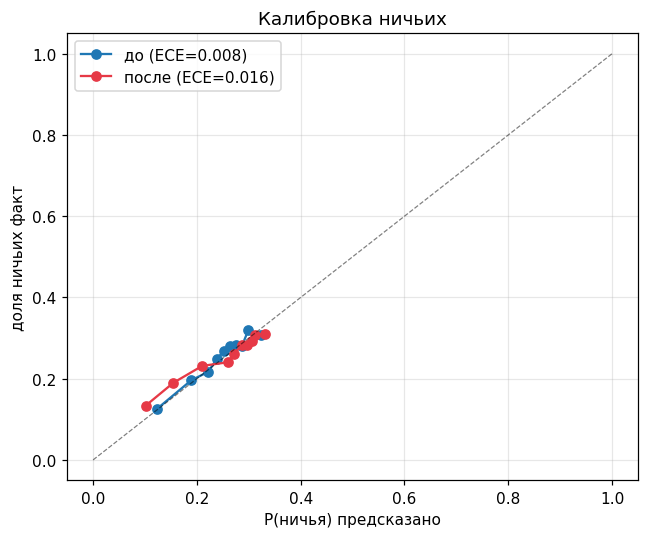

In [6]:
y = (cal['target'] == 'D').astype(int).values
fig, ax = plt.subplots(figsize=(6, 5))
for prefix, name, color in [('raw', 'до', '#1f77b4'), ('cal', 'после', '#E63946')]:
    frac, mp = calibration_curve(y, cal[f'{prefix}_draw'], n_bins=10, strategy='quantile')
    ax.plot(mp, frac, 'o-', color=color, label=f'{name} (ECE={ece(y, cal[f"{prefix}_draw"].values):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('P(ничья) предсказано'); ax.set_ylabel('доля ничьих факт')
ax.set_title('Калибровка ничьих'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Итог

- **Сырые вероятности уже калиброваны** (ECE ~0.01) благодаря log-loss objective XGBoost. Это не случайность: proper scoring rule сам ведёт к калиброванности.
- **Isotonic на одном val-сезоне слегка навредил** уже хорошим вероятностям (draw/away ECE вырос). Урок: калибратор нужно фитить на достаточной выборке, а ренормировка независимых one-vs-rest изотоников искажает.
- При честном рефите на достаточных данных **isotonic марджинально помогает и бьёт Platt** по ECE во всех исходах — выбор метода обоснован эмпирически, а не по умолчанию.
- Ничьи — самый трудный класс, там калибровка важнее всего.
- Главный урок: эффект калибровки надо **измерять**, а не предполагать по умолчанию.

Это ровно приоритет команды: вероятность идёт и в бизнес-решение, и в разговор со стейкхолдером, поэтому её честность проверяется, а не постулируется.